## **DNLS Model Learned by SREINet**


## **I. Setup and Preprocessing**


In [3]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Set TensorFlow log level to '2' to suppress most messages except warnings and errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append("../utilities")

# Import necessary libraries for deep learning and numerical computation
import tensorflow as tf
import numpy as np
from SREINet import * 
import DataGenerator as DG

# Print a formatted message to the terminal to display current time, date, and TensorFlow version
print("**********************************************")
print("*                                            *")
print("*    Tensorflow Version: " + tf.__version__ + "              *")
print("*                                            *")
print("**********************************************")

from packaging import version
if version.parse(tf.__version__) > version.parse('2.10.0'):
    print("Error: Tensorflow version is higher than 2.10. Please use Tensorflow 2.10 or lower.")
    sys.exit()

MY_DATA_TYPE = 'float32'
# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  


**********************************************
*                                            *
*    Tensorflow Version: 2.10.0              *
*                                            *
**********************************************


### **1.2 Training Data**

#### Create dataset

Guess highest order polynomial: 3
(160000, 50)


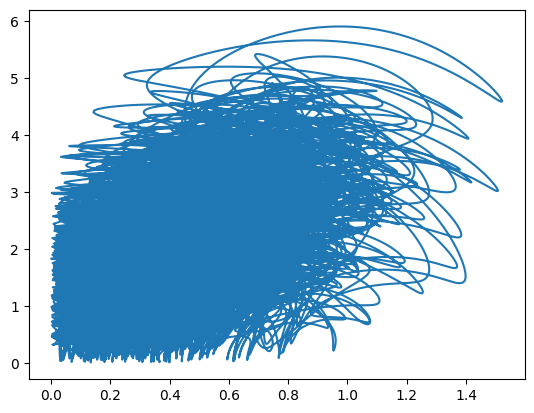

Training input shape: (160000, 100)
Training output shape: (160000, 100)


In [4]:
# Specify the model type
MY_MODEL = 'dnls'  

SEED = 42  # set seed for random number generation
np.random.seed(SEED)

# Generate data based on the specified model type
node_num = 50
C = 2.0 #coupling strength
xn = np.linspace(-node_num/2/np.sqrt(C), node_num/2/np.sqrt(C), node_num)
  
num_traj = 16
v = np.linspace(0.0, 0.99, num_traj)
data_initial_conditions= []
for i in range(num_traj):
        
        #trajectory shape 1
        amp = np.random.normal(0, 0.5, node_num)
        phase = np.random.uniform(0, 2*np.pi, node_num)
        new_IC = amp*np.cos(phase) + 1j*amp*np.sin(phase)
        data_initial_conditions.append(new_IC)
        

data_T =  100.0       # Length of the data (T)
data_dt = 0.01       # Resolution of the data (dt)
myDG = DG.DataGenerator(data_initial_conditions,T=data_T, dt=data_dt, random_state=SEED)
t_arr, x_train, dx_train, guess_highest_order_polynomial = myDG.generate_dataset_by_model_name(MY_MODEL, C, node_num, method="DOP853")

print("Guess highest order polynomial:", guess_highest_order_polynomial)

import matplotlib.pyplot as plt
print(x_train.shape)
plt.plot(np.abs(x_train[:,0]), np.abs(dx_train[:,0]))
plt.show()

x_train = np.concatenate((np.real(x_train), np.imag(x_train)), axis=1)
dx_train = np.concatenate((np.real(dx_train), np.imag(dx_train)), axis=1)
#Shuffle data
training_input, training_output = x_train, dx_train
# Optionally, save a copy of the training input for simulation
training_input_for_sim = training_input.copy() # Saving a copy of training input for simulation (Before shuffling)

np.random.seed(SEED)

training_input, training_output = myDG.shuffleData(training_input, training_output)

print("Training input shape:", training_input.shape)
print("Training output shape:", training_output.shape)

(9999, 1)
(10000, 100)


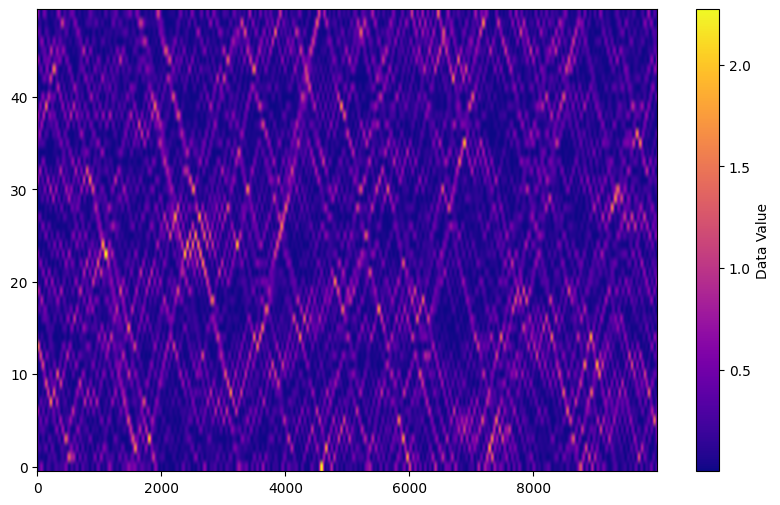

In [5]:
import seaborn as sns

heatmap_t_arr = t_arr[:-1:1]

heatmap_x_train = x_train[:t_arr.shape[0],]
print(heatmap_t_arr.shape)
print(heatmap_x_train.shape)

phi_data = heatmap_x_train[:,0:node_num]**2 + heatmap_x_train[:,node_num:2*node_num]**2
phi_data = phi_data.transpose()
#downsample
plt.figure(figsize=(10, 6))
#a1= sns.heatmap(heat_map_dx_train, cmap='viridis', xticklabels=heatmap_t_arr, yticklabels=np.arange(heat_map_dx_train.shape[0]))
#a1.set_xticks([0,2.5, 5, 7.5, 10.])
#plt.imshow(heat_map_dx_train, aspect='auto', cmap='viridis', extent=[heatmap_t_arr[0], heatmap_t_arr[-1], 0, heat_map_dx_train.shape[0]])

import matplotlib.colors as mcolors

plt.imshow(phi_data, aspect='auto', cmap='plasma')

step = 400

plt.colorbar(label='Data Value')
plt.gca().invert_yaxis()

plt.show()

### **1.3 Hyperparameters**

In [6]:
# Set mini-batch size
MINI_BATCH_SIZE = 512
learning_rate = 0.005

### **1.4 Model Architecture Definitions**

**SREINet Parameters**

In [7]:
# Assign dim to be the 2nd dimension of the training data (number of input variables, including the added constant 1)
dim = training_input.shape[1] 

# The grid size of each dimension
layer_neuron_nums_per_act_fn = [dim] * guess_highest_order_polynomial
print(layer_neuron_nums_per_act_fn)

[100, 100, 100]


## **II. Model and Training Preparation**

### **2.1 Create the SREINet Model**

In [7]:
activation_fns = [lambda x:x]
inputs = tf.keras.layers.Input(shape=(dim,), dtype=MY_DATA_TYPE)
model = SREINet(layer_neuron_nums_per_act_fn, 
                     activations=activation_fns,
                     data_type=MY_DATA_TYPE,
                     weight_initializer=tf.initializers.RandomNormal(stddev=1e-4, seed=SEED),
                     name='SREINet')
output = model(inputs)
model = tf.keras.Model(inputs=inputs, outputs=output)

def reinitialize_model_weights(model):
    if hasattr(model.layers[1], 'reinitialize_weights'):
            tf.random.set_seed(np.random.randint(10000))
            model.layers[1].reinitialize_weights()
    else:
        print("SREINet does not have a reinitialize_weights() function.")


/opt/anaconda3/envs/tf/lib/python3.10/site-packages/keras/initializers/initializers_v2.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


### **2.2 Loss Function**

In [8]:
LOSS_FUNCTION = 'mse' #This can be 'MSE', 'LASSO', or 'RIDGE' or 'ElasticNet'(case insensitive). We found MSE is the best.

from loss import *

# Example of selecting a loss function
loss_fn = myLoss(model, LOSS_FUNCTION) 

### **2.3 Optimizer**

In [9]:
#my_optimizer = tf.keras.optimizers.Adam() 
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  # Create an Adam optimizer with the defined learning rate

### **2.4 Defining the Training Loop**


In [10]:
import time
np.set_printoptions(threshold=np.inf)

# Define a training step function
@tf.function
def train_step(model, optimizer, loss_fn, inputs, targets, binary_mask):        
    with tf.GradientTape() as tape:
        # Generate predictions and calculate loss
        predictions = model(inputs, training=False)
        # predictions = model(inputs, training=False)        
        loss = loss_fn(targets, predictions)   
        
    # Calculate gradients and update model weights
    gradients = tape.gradient(loss, model.trainable_variables)        

    # Assuming binary_masks_ones is a list of binary masks created for each trainable variable
    masked_gradients = [tf.multiply(grad, mask) for grad, mask in zip(gradients, binary_mask)]

    optimizer.apply_gradients(zip(masked_gradients, model.trainable_variables))

    return loss

# Define a validation step function
@tf.function
def val_step(model, loss_fn, inputs, targets):
    # Generate predictions and calculate loss for validation data
    predictions = model(inputs, training=False)
    # predictions = model(inputs, training=False) 
    v_loss = loss_fn(targets, predictions)
    # Record the validation loss
    return v_loss   


def SREINet_fit_w_pruning(
    model,              # TensorFlow model to be trained
    training_input,     # Input features for training
    training_output,    # Target outputs for training
    batch_size,         # Number of samples per batch of computation
    validation_split,   # Fraction of data to be used as validation set
    epochs,             # Number of complete passes through the training dataset
    optimizer,          # Optimization algorithm for updating weights
    loss_fn,            # Loss function to measure model's performance
    pruning_schedule,   # Pruning schedule for gradually increasing the sparsity level
    data_type='float32',    # Data type of the tensors (default: 'float32')
    callbacks=None,         # List of callbacks for custom actions at various stages of training
    early_stopping_loss_threshold=1e-6,       # Threshold for early stopping based on training and validation loss
    early_stopping_pruning_threshold=1e-6,    # Threshold for early stopping based on pruning threshold
    verbose=0,               # Verbosity mode (0 = silent, 1 = progress bar, etc.)
):

    # Cast the training input and output to the specified data type
    training_input = tf.cast(training_input, data_type)
    training_output = tf.cast(training_output, data_type)

    # Shuffle and batch the dataset, then split it into training and validation sets
    full_dataset = tf.data.Dataset.from_tensor_slices((training_input, training_output)).shuffle(buffer_size=1024)
    total_samples = training_input.shape[0]
    train_samples = int(total_samples * (1 - validation_split))
    
    # Apply the data type casting for each batch in the datasets
    train_dataset = full_dataset.take(train_samples).batch(batch_size).map(lambda x, y: (tf.cast(x, data_type), tf.cast(y, data_type)))
    val_dataset = full_dataset.skip(train_samples).batch(batch_size).map(lambda x, y: (tf.cast(x, data_type), tf.cast(y, data_type)))

    # Initialize metrics for tracking training and validation loss
    train_loss = tf.keras.metrics.Mean(name='train_loss', dtype=data_type)
    val_loss = tf.keras.metrics.Mean(name='val_loss', dtype=data_type)
    
    # Parameters initialization
    binary_mask = [tf.ones_like(var) for var in model.trainable_variables]

    def prune_the_model(model, pruning_weight_threshold, existing_masks):
        binary_masks = []  # Initialize list to hold binary masks
        
        # Iterate over each variable to apply the pruning threshold and generate masks
        for var in model.trainable_variables:
            # Generate a binary mask where weights above the PRUNING_WEIGHT_THRESHOLD are marked with 1, others with 0
            mask = tf.cast(tf.abs(var) >= pruning_weight_threshold, var.dtype)

            # Update the mask at position (0, 0) to be 1 using tf.tensor_scatter_nd_update (To Avoid the constant term being pruned)
            indices = tf.constant([[0, 0]])  # Specify the indices to update
            updates = tf.constant([1], dtype=mask.dtype)  # Specify the value to update
            mask = tf.tensor_scatter_nd_update(mask, indices, updates)

            binary_masks.append(mask)  # Add the generated mask to the list            

            # Apply mask to modify weights by setting weights below PRUNING_WEIGHT_THRESHOLD to zero
            modified_weight = var * mask
            var.assign(modified_weight)            
        return binary_masks

    # Prepare a dictionary to track the training history
    history = {'loss': [], 'val_loss': []}

    # Before the training loop starts
    if callbacks:
        for callback in callbacks:
            # Assign the model to the callback
            callback.set_model(model)

            # Manually setting params before calling any methods that might depend on them
            callback.params = {
                'epochs': epochs,  # Number of epochs
                # You can add more parameters here as needed
            }

            # Now call on_train_begin with all properties set
            callback.on_train_begin(logs={'loss_threshold': early_stopping_loss_threshold})

    training_start_time = time.time()
    # Execute the training loop
    for epoch in range(epochs):
        # Notify callbacks that the epoch has started

        if callbacks:
            epoch_logs = {}
            for callback in callbacks:
                callback.on_epoch_begin(epoch, logs=epoch_logs)

        if verbose: 
            eopoch_start_time = time.time()

        # Reset state of metrics at the start of each epoch
        train_loss.reset_states()
        val_loss.reset_states()

        # Retrieve the current pruning schedule threshold
        current_pruning_threshold = pruning_schedule[epoch % len(pruning_schedule)]
        binary_mask = prune_the_model(model,current_pruning_threshold, binary_mask)
        
        layer_losses_sum = None
        layer_indices = [i for i, layer in enumerate(model.layers) if layer.trainable]
        # Process each batch in the training dataset
        for train_inputs, train_targets in train_dataset:           
            loss = train_step(model = model, 
                            optimizer = optimizer, 
                            loss_fn = loss_fn,
                            inputs = train_inputs, 
                            targets = train_targets, 
                            binary_mask = binary_mask)    
            # Record the loss
            train_loss(loss)

        # Process each batch in the validation dataset
        for val_inputs, val_targets in val_dataset:
            v_loss = val_step(model = model, 
                                loss_fn = loss_fn,
                                inputs = val_inputs, 
                                targets = val_targets)
            val_loss(v_loss)

        # Append the average losses for this epoch to the history
        history['loss'].append(train_loss.result().numpy())
        history['val_loss'].append(val_loss.result().numpy())
        
        # Current Losses
        current_train_loss = train_loss.result().numpy()
        current_val_loss = val_loss.result().numpy()
        
        # Notify callbacks that the epoch has ended
        epoch_logs = {'loss': current_train_loss, 'val_loss': current_val_loss}
        if callbacks:
            for callback in callbacks:
                callback.on_epoch_end(epoch, logs=epoch_logs)
    
        if verbose:
            epoch_time = time.time() - eopoch_start_time
            total_layers = len(model.layers)
            trainable_layer_count = sum(1 for layer in model.layers if layer.trainable)
            print(f"Epoch {epoch + 1:3.0f}:"
                f"  Train Loss: {current_train_loss:4.3e}"
                f",  Validation Loss: {current_val_loss:4.3e}"
                # f",  Trainable Layers ({trainable_layer_count}/{total_layers})"
                f",  Epoch Time: {epoch_time:.2f}s"  
                f",  Current Pruning Threshold: {current_pruning_threshold:.5g}")     

        # Check for early stopping
        if current_train_loss < early_stopping_loss_threshold and current_pruning_threshold > early_stopping_pruning_threshold:
            print(f"Early stopping at epoch {epoch+1} as train loss {current_train_loss:.14f} is below the threshold {early_stopping_loss_threshold:.14f}")
            break


    # After the training loop ends
    training_time = time.time() - training_start_time
    print(f'Traininng Stopped. Time elapsed: {training_time:.2f}s')
    if callbacks:
        for callback in callbacks:
            callback.on_train_end(logs={'final_loss': current_train_loss, 'final_val_loss': current_val_loss})
    

    # Return the history containing training and validation losses
    return history

## **III.Training the Model**

#### **Setup of Pruning Profile**


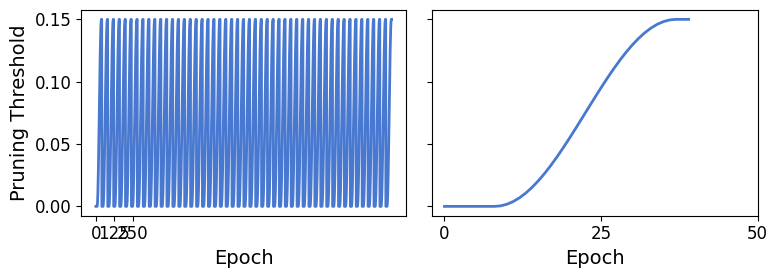

In [11]:
PRUNING_WEIGHT_THRESHOLD = 0.15
N_PERIODS = 50
PRUNING_EPOCHS_PER_PERIOD = 40
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS

import pruning_schedule as ps


# Define the pruning schedule
pruning_schedule = ps.pruning_schedule_ramp(maximum_threshold=PRUNING_WEIGHT_THRESHOLD, 
                                                    steps_per_period=PRUNING_EPOCHS_PER_PERIOD,
                                                    zero_percentage=0.20, 
                                                    num_periods=N_PERIODS, 
                                                    show_plot=True)


#### **Training**


In [12]:
callbacks = []

EARLY_STOPPING_LOSS_THRESHOLD = 1e-10   # Threshold for early stopping (Layer Based)
EARLY_STOPPING_PRUNING_THRESHOLD = 0.05 # Threshold for early stopping (Pruning Based)

training_histories = []
weights_list = []
print(f"Total Dimensions: {training_output.shape[1]}")
for i in range(training_output.shape[1]):
    print(f"Training dimension {i + 1}...")
    
    output = training_output[:, i:i+1]

    history = SREINet_fit_w_pruning(
        model,                   # Model to train
        training_input,             # Input data for training
        output,                     # Output data for training
        batch_size=MINI_BATCH_SIZE, # Number of samples per gradient update
        validation_split=0.20,      # Fraction of the training data to be used as validation data
        epochs=round(NUM_EPOCHS),   # Number of times the entire training dataset is passed through the model
        optimizer=my_optimizer,     # Optimizer to use for training
        pruning_schedule = pruning_schedule, # Pruning schedule for gradually increasing the sparsity level
        loss_fn=loss_fn,            # Loss function to use for training
        data_type=MY_DATA_TYPE,     # Data type to use for training
        callbacks= callbacks,       # List of callbacks to apply during training
        early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,# Threshold for early stopping (Layer Based)
        early_stopping_pruning_threshold=EARLY_STOPPING_PRUNING_THRESHOLD, # Threshold for early stopping (Pruning Based
        verbose=1,                   # Hide the epoch steps
    )
    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([model.get_layer('SREINet').get_weights()])
    #reset the weights
    reinitialize_model_weights(model)

Total Dimensions: 100
Training dimension 1...
Epoch   1:  Train Loss: 3.325e-01,  Validation Loss: 1.039e-02,  Epoch Time: 0.80s,  Current Pruning Threshold: 0
Epoch   2:  Train Loss: 6.020e-03,  Validation Loss: 4.059e-03,  Epoch Time: 0.57s,  Current Pruning Threshold: 0
Epoch   3:  Train Loss: 5.916e-03,  Validation Loss: 7.449e-03,  Epoch Time: 0.55s,  Current Pruning Threshold: 0
Epoch   4:  Train Loss: 1.105e-02,  Validation Loss: 1.157e-02,  Epoch Time: 0.54s,  Current Pruning Threshold: 0
Epoch   5:  Train Loss: 6.613e-03,  Validation Loss: 6.250e-03,  Epoch Time: 0.54s,  Current Pruning Threshold: 0
Epoch   6:  Train Loss: 5.702e-03,  Validation Loss: 6.295e-03,  Epoch Time: 0.55s,  Current Pruning Threshold: 0
Epoch   7:  Train Loss: 1.108e-02,  Validation Loss: 1.320e-02,  Epoch Time: 0.55s,  Current Pruning Threshold: 0
Epoch   8:  Train Loss: 1.056e-02,  Validation Loss: 9.519e-03,  Epoch Time: 0.55s,  Current Pruning Threshold: 0
Epoch   9:  Train Loss: 1.153e-02,  Valida

/opt/anaconda3/envs/tf/lib/python3.10/site-packages/keras/initializers/initializers_v2.py:120: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


Epoch   1:  Train Loss: 3.380e-01,  Validation Loss: 1.507e-02,  Epoch Time: 0.60s,  Current Pruning Threshold: 0
Epoch   2:  Train Loss: 4.495e-03,  Validation Loss: 1.902e-03,  Epoch Time: 0.57s,  Current Pruning Threshold: 0
Epoch   3:  Train Loss: 1.329e-03,  Validation Loss: 9.773e-04,  Epoch Time: 0.58s,  Current Pruning Threshold: 0
Epoch   4:  Train Loss: 7.694e-04,  Validation Loss: 6.549e-04,  Epoch Time: 0.57s,  Current Pruning Threshold: 0
Epoch   5:  Train Loss: 5.740e-04,  Validation Loss: 6.319e-04,  Epoch Time: 0.57s,  Current Pruning Threshold: 0
Epoch   6:  Train Loss: 7.704e-04,  Validation Loss: 4.675e-03,  Epoch Time: 0.58s,  Current Pruning Threshold: 0
Epoch   7:  Train Loss: 3.930e-03,  Validation Loss: 6.710e-03,  Epoch Time: 0.57s,  Current Pruning Threshold: 0
Epoch   8:  Train Loss: 8.556e-03,  Validation Loss: 6.221e-03,  Epoch Time: 0.58s,  Current Pruning Threshold: 0
Epoch   9:  Train Loss: 2.371e-03,  Validation Loss: 1.252e-03,  Epoch Time: 0.58s,  Cur

## **IV. Coefficient Reconstructor (SREINet)**

After training, we need to fomulate the identified model by reconstructing the coefficients of the SREINet.


#### `generate_set_labels`
This function generates the labels for the neurons in the SREINet and the LHS of the ODEs.

In [13]:
def generate_set_labels(N):
    N = int(N/2)
    return ['Constant'] + [f'a{i}' for i in range(1, N+1)] + [f'b{i}' for i in range(1, N+1)]
def generate_LHS_labels(N):
    N = int(N/2)
    return [f"(a{i})'" for i in range(1, N+1)] + [f"(b{i})'" for i in range(1, N+1)]

#### `coefficient_reconstruction`

In [14]:
def coefficient_reconstruction(dim_index,
                               num_activation_fns,
                                weights, 
                                minimum_coefficient_threshold = 1e-5,
                                coefficient_output_digits = 10, 
                                enable_coefficient_sorting = False):
    
    max_neurons = int((max(max(len(layer) for layer in SREINet) for SREINet in weights) - 1)/num_activation_fns)
    
    labels = generate_set_labels(max_neurons) # number of states = number of neurons - 1
    LHS_labels = generate_LHS_labels(max_neurons)

    def explore_path(SREINet_index, layer, neuron, weight_product, label_counts, non_zero_paths):
        """
        Recursively explores non-zero paths in a neural network.
        """
        if layer == len(weights[SREINet_index]) - 1:
            non_zero_paths.append((label_counts, weight_product))
            return

        for next_neuron, weight in enumerate(weights[SREINet_index][layer][neuron]):
            if abs(weight) <= 1e-15:
                # Skip recursion if the weight is zero (if one weight is zero, the whole path will be eliminated)
                continue  
            new_weight_product = weight_product * weight
            next_label_counts = label_counts.copy()
            next_label_counts[labels[next_neuron]] = next_label_counts.get(labels[next_neuron], 0) + 1
            explore_path(SREINet_index, layer + 1, next_neuron, new_weight_product, next_label_counts, non_zero_paths)
    
    #beginning of the algorithm
    all_SREINet_products = []
    for SREINet_index, _ in enumerate(weights):
        non_zero_paths = []
        #collect all non-zero paths
        for neuron_index in range(len(weights[SREINet_index][0])):
            label_counts = {labels[neuron_index]: 1}
            explore_path(SREINet_index, 0, neuron_index, 1, label_counts, non_zero_paths)
        
        #sum up the products with identical composite nonlinear/linear terms
        SREINet_products = {}
        for label_counts, weight_product in non_zero_paths:
            label_counts_key = frozenset(label_counts.items())
            if label_counts_key in SREINet_products:
                SREINet_products[label_counts_key] += weight_product
            else:
                SREINet_products[label_counts_key] = weight_product
        
        #remove the negligible composite terms
        SREINet_products = {k: v for k, v in SREINet_products.items() if abs(v) >= minimum_coefficient_threshold}
        
        if enable_coefficient_sorting:
            #sort the composite terms by their absolute values
            sorted_SREINet_products = dict(sorted(SREINet_products.items(), key=lambda item: abs(item[1]), reverse=True))
        else:
            sorted_SREINet_products = SREINet_products

        all_SREINet_products.append(sorted_SREINet_products)

    #output formatting
    labeled_all_SREINet_products = []
    for SREINet_index, sorted_SREINet_products in enumerate(all_SREINet_products):
        SREINet_product_strings = []
        for key, value in sorted_SREINet_products.items():
            labels_list = []
            only_constant = len(key) == 1 and any(label == 'Constant' for label, _ in key)
            
            for label, count in sorted(key):
                if label == 'Constant' and len(key) > 1:
                    continue
                if label != 'Constant' and count > 1:
                    labels_list.append(f"{label}^{count}")
                elif label == 'Constant' or count == 1:
                    labels_list.append(label if label != 'Constant' else '')
            
            label_str = '*'.join(filter(None, labels_list))
                        
            # Apply coefficient threshold if enabled
            formatted_value = f"{abs(value):.{coefficient_output_digits}g}"

            term_str = label_str if formatted_value == '1' else f"{formatted_value}*{label_str}" if not only_constant else formatted_value if formatted_value != '1' else ''
            sign = '+' if value >= 0 else '-'
            if SREINet_product_strings or value < 0:
                term_str = f" {sign} {term_str}"
            else:
                term_str = term_str
            SREINet_product_strings.append(term_str)

        formatted_output = ''.join(SREINet_product_strings)
        #layer_prefix = f"(x{SREINet_index+dim_index+1})'= "
        layer_prefix = LHS_labels[SREINet_index+dim_index]  + "="
        full_output = layer_prefix + formatted_output
        labeled_all_SREINet_products.append(full_output)

    return labeled_all_SREINet_products

## **V. Results**
### **Identified Model**

In [16]:
for i in range(len(weights_list)):
    path_products = coefficient_reconstruction(i,
                                               len(activation_fns),
                                               weights_list[i], 
                                            minimum_coefficient_threshold = 2e-1,
                                            coefficient_output_digits = 10, 
                                            enable_coefficient_sorting = False)
    
    for index, dimension in enumerate(path_products):
        print(f"{dimension}")

(a1)'= - 1.999999906*b2 + 3.99999988*b1 - 0.9999998209*a1^2*b1 - 0.9999998414*b1^3 - 2.000000154*b50
(a2)'= - 2.000000007*b1 + 4.000000015*b2 - 2.000000007*b3 - 0.9999999576*a2^2*b2 - 0.9999999743*b2^3
(a3)'= - 2.0000001*b2 + 4.000000199*b3 - 2.0000001*b4 - 1.000000404*a3^2*b3 - 0.9999998923*b3^3
(a4)'= - 1.000000008*a4^2*b4 - 1.999999949*b3 + 3.999999898*b4 - 1.000000008*b4^3 - 1.999999949*b5
(a5)'= - 2.000000019*b4 + 4.000000038*b5 - 2.000000019*b6 - 1.000000037*a5^2*b5 - 1.000000065*b5^3
(a6)'= - 1.999999987*b5 + 3.999999974*b6 - 1.999999987*b7 - 0.9999998763*a6^2*b6 - 0.9999999521*b6^3
(a7)'= - 1.999999926*b6 + 3.999999853*b7 - 1.000000012*a7^2*b7 - 1.000000014*b7^3 - 1.999999926*b8
(a8)'= - 0.9999999124*a8^2*b8 - 1.999999995*b7 + 3.999999989*b8 - 0.9999999601*b8^3 - 1.999999995*b9
(a9)'= - 2.000000028*b8 + 4.000000056*b9 - 2.000000028*b10 - 1.000000982*a9^2*b9 - 0.9999998735*b9^3
(a10)'= - 0.9999995406*a10^2*b10 - 2.000000101*b9 + 4.000000201*b10 - 0.9999995903*b10^3 - 1.999999744

### **Validation**


313/313 [==============================] - 0s 203us/step


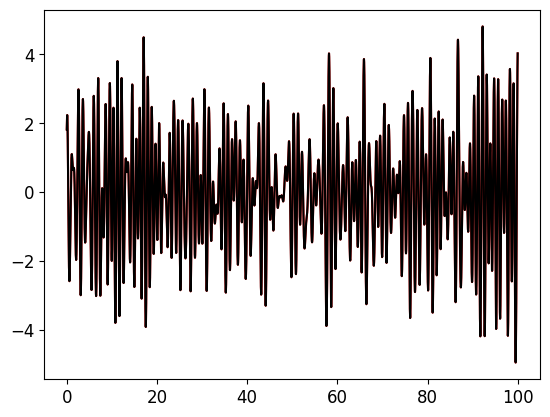

In [17]:
import matplotlib.pyplot as plt

# validation: need to draw the output of each dimension independently
dim_to_plot = 1
index = dim_to_plot - 1

#Form NN predictions
NN_output = np.zeros((dx_train.shape[0], dx_train.shape[1]))
for i, weight in enumerate(weights_list):
    model.get_layer('SREINet').set_weights(weight[0])
    output = model.predict(training_input_for_sim)
    NN_output[:,i:i+1] = output


#validate the first trajoctory if there are many
plt.plot(t_arr, NN_output[:,index][:t_arr.shape[0]], 'r', label='NN Prediction')
plt.plot(t_arr, dx_train[:,index][:t_arr.shape[0]], 'k', label='Expected Output')

#pick the last point of the simulation output and use it as the initial condition for the next simulation
x0 = x_train[:t_arr.shape[0]][-1]
x0 = x0[0:node_num] + 1j*x0[node_num:2*node_num]
t0= t_arr[-1]
myDG = DG.DataGenerator(x0,T=data_T+t0+data_dt, dt=data_dt, t0=t0)
new_t_arr, new_x, new_dx, guess_highest_order_polynomial = myDG.generate_dataset_by_model_name(MY_MODEL, C, node_num)

new_input = np.concatenate((np.real(new_x), np.imag(new_x)), axis=1)

new_NN_output= np.zeros((new_dx.shape[0], new_dx.shape[1]))
for i, weight in enumerate(weights_list):
    model.get_layer('SREINet').set_weights(weight[0])
    output = model.predict(new_input)
    new_NN_output[:,i:i+1] = output


#new_NN_output = model.predict(new_input)
#plt.plot(new_t_arr, new_NN_output[:,index], "r--", label='NN Prediction')
#plt.plot(new_t_arr, new_dx[:,index], "k--", label='Expected Output')
#plt.title("Response of dimension " + str(dim_to_plot))
#plt.show()


## **VI. Output**

In [19]:
#save data
opt_folder = 'output'
# Create the folder if it doesn't exist
os.makedirs(opt_folder, exist_ok=True)

import pandas as pd

df = pd.DataFrame({
    'ODE model': [MY_MODEL],
    'data initial conditions': [data_initial_conditions],
    'data length (T)': [data_T],
    'data resolution (dt)': [data_dt],
    'learning rate': [learning_rate],
    'Guess highest-order polynomial': [guess_highest_order_polynomial],
    'input dimension': [x_train.shape[1]],
    'mini_batch_size': [MINI_BATCH_SIZE],
    'Layer Neurons per activation fns': [layer_neuron_nums_per_act_fn],
    'Data Points': [training_input.shape[0]],
    'loss function': [LOSS_FUNCTION],
    'Total Training Epochs': [NUM_EPOCHS],
    'last lost value': [history['loss'][-1]],
    'weight threshold for pruning': [PRUNING_WEIGHT_THRESHOLD],
    'loss threshold for early stopping': [EARLY_STOPPING_LOSS_THRESHOLD],
})

In [20]:
#write df to the first sheet of the excel file
#write to folder named data

opt_folder = 'output'
# Create the folder if it doesn't exist
os.makedirs(opt_folder, exist_ok=True)

with pd.ExcelWriter(os.path.join(opt_folder,'nn_configurations.xlsx')) as writer:

    df.to_excel(writer, sheet_name='configuration', index=False)

    #save the loss and validation history to the second sheet of the excel file
    df2 = pd.DataFrame(history)
    df2.to_excel(writer, sheet_name='loss_history', index=False)

    #save reconstructed weights to the third sheet of the excel file

    df3 = []

    for i in range(len(weights_list)):
        path_products = coefficient_reconstruction(i,
                                                    len(activation_fns),
                                                    weights_list[i], 
                                                    minimum_coefficient_threshold = 1e-2,
                                                    coefficient_output_digits = 10, 
                                                    enable_coefficient_sorting = False)


        # Convert path_products to a DataFrame
        temp_df = pd.DataFrame(path_products)

        # Append temp_df to df3
        df3.append(temp_df)

    df3 = pd.concat(df3, ignore_index=True)
    df3.to_excel(writer, sheet_name='reconstructed_weights', index=False)

In [ ]:
from scipy.io import savemat
#concatenate t_arr, x_train, dx_train, and NN_output and save it as a mat file

#pate t_arr such that it has the same shape as x_train, dx_train, and NN_output

m_data = np.concatenate((t_arr, x_train, dx_train, NN_output), axis=1)
savemat(os.path.join(opt_folder,'train_data.mat'), {'data': m_data})

v_data = np.concatenate((new_t_arr, new_x, new_dx, new_NN_output), axis=1)
savemat(os.path.join(opt_folder,'validation_data.mat'), {'data': v_data})